# scRNA assay batch-effect model (F3 demo)

This notebook is the per-module deep-dive for the **scRNA assay** (`src/iscc/data/{assay,batch,rna}.py`,
DESIGN_features §B / milestone **F3**). It starts from a realistic upstream input — a tumour
**dissociation / sample** — and **sweeps the key technical parameters**, showing their effect on the
output while keeping the **ground truth (clone, type, coords) surfaced**.

Model (DESIGN_features §B.2), for cell *c*, gene *g*, batch *b*, biology $\lambda_{cg}$ = `cell_exp`:

$$\beta_{gb}\sim\text{LogNormal}(0,\sigma_\text{batch}^2),\quad
\ell_c\sim\text{LogNormal}(\mu_{\text{lib},b},\sigma_\text{lib}^2),\quad
y_{cg}\sim\text{NB}(\ell_c\,\tilde\beta_{gb}\lambda_{cg},\ \phi_b)$$

plus ambient soup + doublets (+ optional dropout). The count emission is **pluggable** (`count_model`,
default `"nb"`). These hyper-parameters are exactly what `estimate()` (DESIGN_inference §B / M2) fits.

**Sweeps:** depth · dispersion · dropout · batch strength / #batches · protocol (10x vs Smart-seq3),
visualized via counts, library-size distribution, UMAP, and batch mixing.

In [1]:
%matplotlib inline
import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

from iscc.data.rna import scRNA, run_scrna_batches, concat_batches, PROTOCOL_PRESETS
from iscc.data.batch import RNABatchHyperParams

sc.settings.verbosity = 0
np.random.seed(0)
NB_DIR = os.getcwd()
OUT = os.path.join(NB_DIR, "example_out")
# Generate the shared example pipeline (tumour -> sample) if needed.
if not os.path.isdir(os.path.join(OUT, "sample", "cell_data")):
    subprocess.run([sys.executable, os.path.join(NB_DIR, "generate_example.py")], check=True)
print("protocol presets:")
pd.DataFrame(PROTOCOL_PRESETS).T

protocol presets:


,sigma_batch,mu_lib,sigma_lib,dispersion,ambient_frac,doublet_rate,dropout_mid,dropout_shape,well_sigma,depth_batch_sigma,kappa
10x,0.1,4000.0,0.35,0.30,0.050,0.05,1.5,1.0,0.00,0.05,50.0
smartseq3,0.1,8000.0,0.45,0.15,0.005,0.01,0.0,1.0,0.15,0.05,50.0


## 1. The dissociation / sample (upstream input)

Load the sampled `cell_data` (the output of `isccsample` — a dissociation/biopsy of the tumour).
We keep `cell_exp` (biological signal $\lambda$), `cell_type` (clone / genotype ground truth) and
`cell_crd` (coords). This is the *biology* every assay below shares.

In [2]:
keys = ["cell_exp", "cell_type", "cell_crd", "cell_snv"]
SAMP = os.path.join(OUT, "sample", "cell_data")
cell_data = {k: pd.read_csv(os.path.join(SAMP, f"{k}.csv"), index_col=0)
             for k in keys if os.path.exists(os.path.join(SAMP, f"{k}.csv"))}
n_cells_avail = cell_data["cell_exp"].shape[0]
clone_col = cell_data["cell_type"].iloc[:, 0]
print(f"{n_cells_avail} cells x {cell_data['cell_exp'].shape[1]} genes")
print("ground-truth clones / types:")
print(clone_col.value_counts())

1448 cells x 6000 genes
ground-truth clones / types:
cell_id
stromal       1348
2               39
epithelial      38
18               3
79               2
516              2
3611             1
750              1
1880             1
292              1
183              1
1623             1
175              1
25               1
426              1
2630             1
3674             1
960              1
749              1
4500             1
2692             1
3677             1
Name: count, dtype: int64


## 2. One batch (10x): counts, library size, UMAP

Run a single 10x batch and surface the result as an AnnData with ground truth in `.obs`.

AnnData object with n_obs × n_vars = 400 × 6000
    obs: 'batch', 'protocol', 'n_counts', 'n_genes', 'is_doublet', 'clone', 'row', 'col'
    uns: 'assay', 'protocol', 'count_model', 'batch_seed', 'hyperparams'
    obsm: 'spatial'
obs columns: ['batch', 'protocol', 'n_counts', 'n_genes', 'is_doublet', 'clone', 'row', 'col']


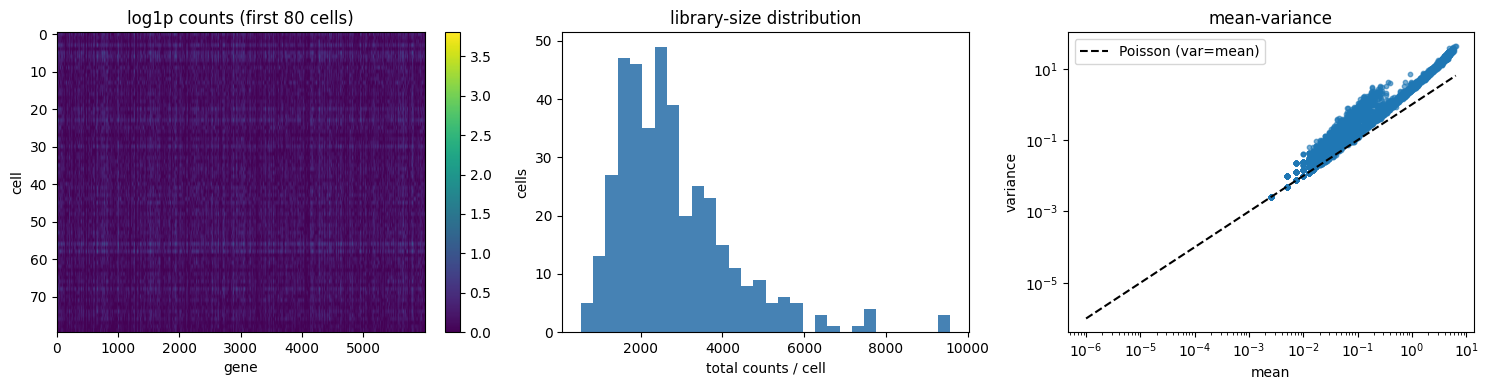

In [3]:
N = min(400, n_cells_avail)
assay = scRNA(protocol="10x", n_cells=N, seed=1).run(cell_data)
adata = assay.to_anndata()
print(adata)
print("obs columns:", list(adata.obs.columns))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# (a) count matrix glimpse
im = axes[0].imshow(np.log1p(adata.X[:80]), aspect="auto", cmap="viridis")
axes[0].set(title="log1p counts (first 80 cells)", xlabel="gene", ylabel="cell")
plt.colorbar(im, ax=axes[0], fraction=0.046)
# (b) library-size distribution
axes[1].hist(adata.obs["n_counts"], bins=30, color="steelblue")
axes[1].set(title="library-size distribution", xlabel="total counts / cell", ylabel="cells")
# (c) mean-variance (overdispersion)
mu = adata.X.mean(0); var = adata.X.var(0)
axes[2].scatter(mu, var, s=10, alpha=0.6)
lim = [mu.min()+1e-6, mu.max()]; axes[2].plot(lim, lim, "k--", label="Poisson (var=mean)")
axes[2].set(xscale="log", yscale="log", title="mean-variance", xlabel="mean", ylabel="variance")
axes[2].legend()
plt.tight_layout()

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


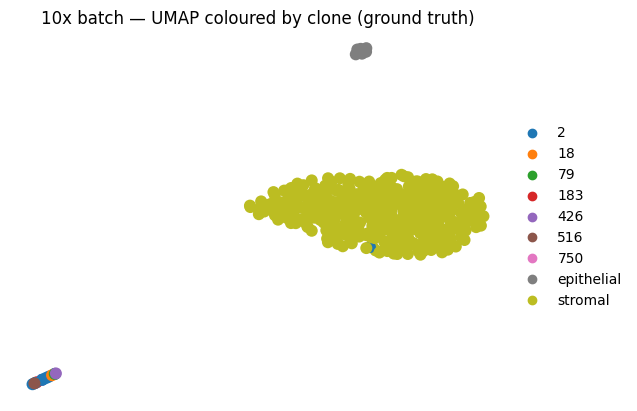

In [4]:
def umap_of(adata, color, title, ax=None):
    a = adata.copy()
    sc.pp.normalize_total(a, target_sum=1e4); sc.pp.log1p(a)
    sc.pp.pca(a, n_comps=min(15, a.n_vars-1, a.n_obs-1))
    sc.pp.neighbors(a, n_neighbors=15); sc.tl.umap(a)
    show = ax is None
    sc.pl.umap(a, color=color, title=title, ax=ax, show=show, frameon=False)
    return a

_ = umap_of(adata, "clone", "10x batch — UMAP coloured by clone (ground truth)")

## 3. Sweep: sequencing depth ($\mu_\text{lib}$ / `n_reads`)

Depth sets the per-cell library size. Deeper → more counts, fewer technical zeros.

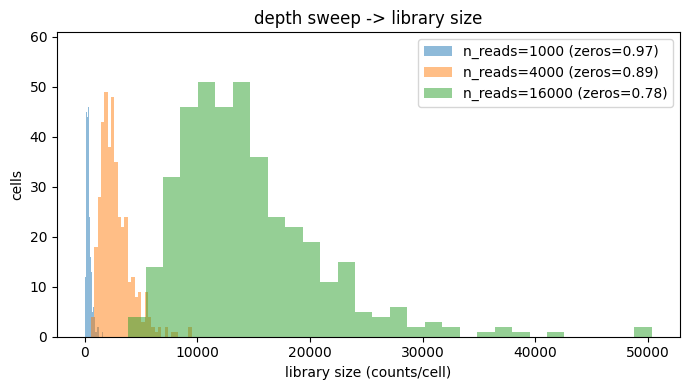

In [5]:
depths = [1000, 4000, 16000]
sub = cell_data["cell_exp"].index[:N]
fig, ax = plt.subplots(figsize=(7, 4))
for d in depths:
    a = scRNA(protocol="10x", n_reads=d, seed=1).run(cell_data, cell_subset=sub)
    libs = a.observed_counts.sum(1).values
    ax.hist(libs, bins=30, alpha=0.5, label=f"n_reads={d} (zeros={ (a.observed_counts.values==0).mean():.2f})")
ax.set(xlabel="library size (counts/cell)", ylabel="cells", title="depth sweep -> library size")
ax.legend(); plt.tight_layout()

## 4. Sweep: NB dispersion $\phi_b$

Dispersion controls overdispersion (var = $\mu + \phi\mu^2$). Higher $\phi$ → noisier, more
zero-inflated counts (and is the parameter `estimate()` reads off the mean-variance trend).

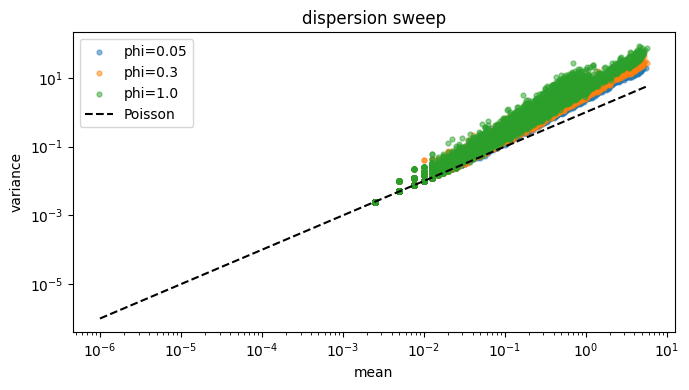

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for phi in [0.05, 0.3, 1.0]:
    a = scRNA(protocol="10x", dispersion=phi, seed=1).run(cell_data, cell_subset=sub)
    X = a.observed_counts.values
    mu, var = X.mean(0), X.var(0)
    ax.scatter(mu, var, s=12, alpha=0.5, label=f"phi={phi}")
lim = [mu.min()+1e-6, mu.max()]; ax.plot(lim, lim, "k--", label="Poisson")
ax.set(xscale="log", yscale="log", xlabel="mean", ylabel="variance", title="dispersion sweep")
ax.legend(); plt.tight_layout()

## 5. Sweep: dropout

Dropout zeros lowly-expressed genes (logistic in expected count; `dropout_mid` is the midpoint).
10x has dropout on by default; Smart-seq3 has it off (higher sensitivity).

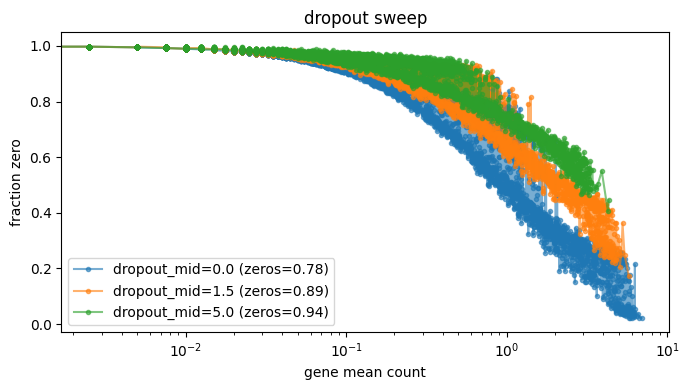

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for mid in [0.0, 1.5, 5.0]:
    a = scRNA(protocol="10x", dropout_mid=mid, seed=1).run(cell_data, cell_subset=sub)
    zf = (a.observed_counts.values == 0).mean()
    gene_mean = a.observed_counts.values.mean(0)
    gene_zero = (a.observed_counts.values == 0).mean(0)
    order = np.argsort(gene_mean)
    ax.plot(gene_mean[order], gene_zero[order], ".-", alpha=0.6, label=f"dropout_mid={mid} (zeros={zf:.2f})")
ax.set(xscale="log", xlabel="gene mean count", ylabel="fraction zero", title="dropout sweep")
ax.legend(); plt.tight_layout()

## 6. Sweep: batch strength $\sigma_\text{batch}$ and number of batches

Two batches share biology (same cells, `design="shared"`) but get different technical signatures.
Larger $\sigma_\text{batch}$ → stronger per-gene batch fold-changes → worse mixing on the UMAP.
We quantify mixing with a simple kBET-style score: the mean fraction of same-batch neighbours
(≈ batch fraction when well-mixed; →1 when fully separated).

In [8]:
from sklearn.neighbors import NearestNeighbors

def batch_separation(adata, k=20):
    a = adata.copy()
    sc.pp.normalize_total(a, target_sum=1e4); sc.pp.log1p(a)
    sc.pp.pca(a, n_comps=min(15, a.n_vars-1, a.n_obs-1))
    nn = NearestNeighbors(n_neighbors=k+1).fit(a.obsm["X_pca"])
    _, idx = nn.kneighbors(a.obsm["X_pca"])
    b = a.obs["batch"].astype("category").cat.codes.values
    same = np.mean([(b[row[1:]] == b[i]).mean() for i, row in enumerate(idx)])
    return same  # ~ 1/n_batches when well mixed, ->1 when separated

for sigma in [0.05, 0.5]:
    assays = run_scrna_batches(cell_data, n_batches=2, base_seed=10, design="shared",
                               protocol="10x", n_cells=N, sigma_batch=sigma)
    comb = concat_batches(assays)
    sep = batch_separation(comb)
    print(f"sigma_batch={sigma}: same-batch-neighbour fraction = {sep:.2f} "
          f"(0.50 = perfectly mixed, 1.0 = fully separated)")

sigma_batch=0.05: same-batch-neighbour fraction = 0.54 (0.50 = perfectly mixed, 1.0 = fully separated)


sigma_batch=0.5: same-batch-neighbour fraction = 0.98 (0.50 = perfectly mixed, 1.0 = fully separated)


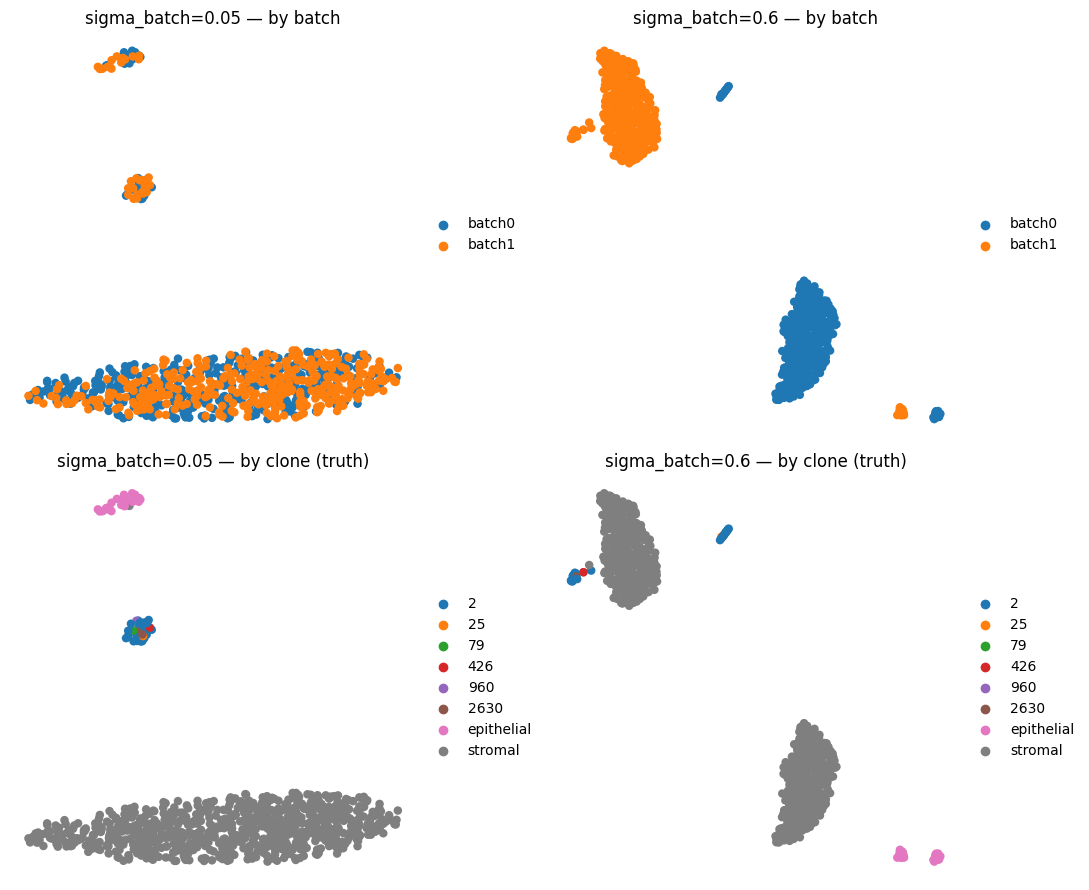

In [9]:
# UMAPs: weak vs strong batch effect, coloured by batch and by clone
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for j, sigma in enumerate([0.05, 0.6]):
    assays = run_scrna_batches(cell_data, n_batches=2, base_seed=10, design="shared",
                               protocol="10x", n_cells=N, sigma_batch=sigma)
    comb = concat_batches(assays)
    a = comb.copy()
    sc.pp.normalize_total(a, target_sum=1e4); sc.pp.log1p(a)
    sc.pp.pca(a, n_comps=min(15, a.n_vars-1, a.n_obs-1))
    sc.pp.neighbors(a); sc.tl.umap(a)
    sc.pl.umap(a, color="batch", title=f"sigma_batch={sigma} — by batch", ax=axes[0, j], show=False, frameon=False)
    sc.pl.umap(a, color="clone", title=f"sigma_batch={sigma} — by clone (truth)", ax=axes[1, j], show=False, frameon=False)
plt.tight_layout()

**Read-out:** with weak batch effect the two batches overlap (and clones drive the structure);
with strong batch effect the batches separate even though the biology is identical — exactly the
labelled benchmark batch-correction methods are evaluated on (the cell↔cell correspondence is known).

## 7. Protocol: 10x vs Smart-seq3

Smart-seq3 (plate, 5′ UMIs, full-length) → higher sensitivity / depth, lower dropout, low
amplification noise (low dispersion), and an extra per-cell **well** effect nested in the plate.

,total_counts,median_lib,frac_zero,genes_per_cell
10x,1098627.0,2442.5,0.886312,682.1275
smartseq3,3209410.0,7084.0,0.737661,1574.0325


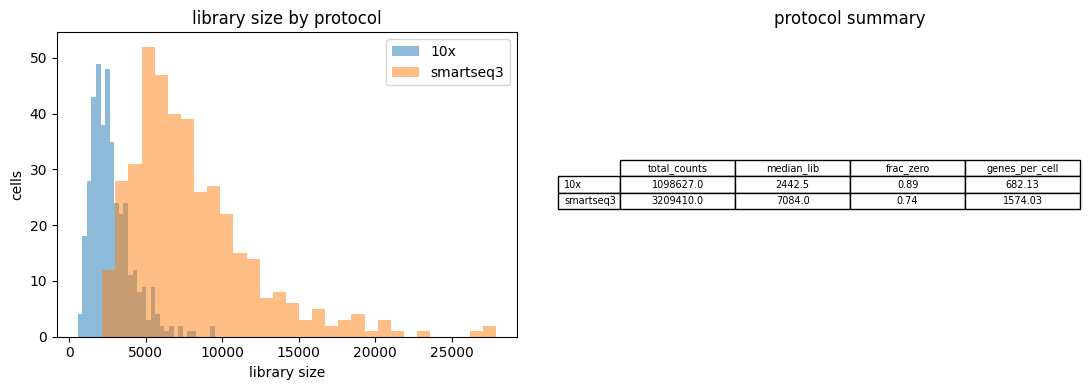

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
summary = {}
for proto in ["10x", "smartseq3"]:
    a = scRNA(protocol=proto, n_cells=N, seed=1).run(cell_data, cell_subset=sub)
    X = a.observed_counts.values
    axes[0].hist(X.sum(1), bins=30, alpha=0.5, label=proto)
    summary[proto] = dict(total_counts=int(X.sum()), median_lib=float(np.median(X.sum(1))),
                          frac_zero=float((X == 0).mean()), genes_per_cell=float((X > 0).sum(1).mean()))
axes[0].set(xlabel="library size", ylabel="cells", title="library size by protocol"); axes[0].legend()
sdf = pd.DataFrame(summary).T
axes[1].axis("off")
axes[1].table(cellText=np.round(sdf.values, 2), rowLabels=sdf.index, colLabels=sdf.columns,
              loc="center", cellLoc="center")
axes[1].set_title("protocol summary")
plt.tight_layout()
sdf

## 8. Writing a labelled multi-batch benchmark

Each batch is written as its own AnnData with `batch` in `.obs` and the ground truth preserved;
`concat_batches` produces the integrated object. From the CLI:

```bash
isccdata sample_out -a scrna --protocol 10x --batches 2 --design shared -o data_scrna
# -> data_scrna/{batch0.h5ad, batch1.h5ad, scrna_all_batches.h5ad}
```

In [11]:
assays = run_scrna_batches(cell_data, n_batches=2, base_seed=10, design="shared",
                           protocol="10x", n_cells=N)
out = os.path.join(OUT, "data_scrna_batches"); os.makedirs(out, exist_ok=True)
for a in assays:
    a.write(out)
concat_batches(assays).write_h5ad(os.path.join(out, "scrna_all_batches.h5ad"))
print("wrote:", sorted(os.listdir(out)))

wrote: ['batch0.h5ad', 'batch1.h5ad', 'scrna_all_batches.h5ad', 'umis.csv']


## 9. Fitting the batch parameters back from data (M2 `estimate`)

The knobs swept above ($\mu_\text{lib}$, dispersion, dropout, batch strength) are the **M2 `estimate()` targets**. Given a dataset, `estimate` fits them (Splatter / scDesign-style) and iscc ships defaults *calibrated* to such fits. Here we fit them back from a simulated batch and check the recovery; `validation/validate_scrna.py` runs the same fit against **real PBMC3k**.

In [12]:
from iscc.data import estimate_rna

a = scRNA(protocol="10x", n_cells=400, seed=1).run(cell_data)
adata = sc.AnnData(X=np.asarray(a.observed_counts.values, dtype=float))
est = estimate_rna(adata, protocol="10x")
print(f"cells fit        : {est.n_cells}")
print(f"library-size CV  : fit {est.cv_lib:.2f}   (real PBMC3k ~0.46)")
print(f"sigma_lib        : fit {est.hypers.sigma_lib:.2f}")
print(f"NB dispersion    : fit {est.hypers.dispersion:.2f}")
print("\nThese are the values iscc's calibrated scRNA defaults are set from.")

cells fit        : 400
library-size CV  : fit 0.51   (real PBMC3k ~0.46)
sigma_lib        : fit 0.48
NB dispersion    : fit 0.72

These are the values iscc's calibrated scRNA defaults are set from.
